In [1]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.validation import make_valid

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')
scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap_12_subprob.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)

# Remove Bhutan from load zones
df_load_ = df_load_[df_load_['load_zone'] != "Bhutan"].reset_index(drop=True)

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17
pier_no_prm_no_ccap_2040_18


# Loss-of-load probability heatmap

In [ ]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
# print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        # print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

# print(LOLP_.max(), LOLP_.min())

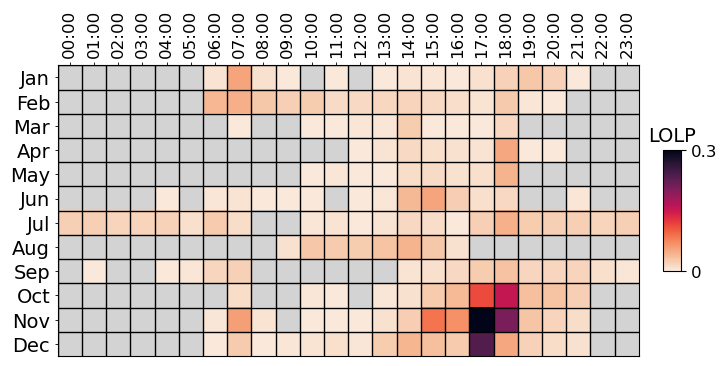

In [4]:

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# --- Put months in calendar order (Jan → Dec) ---
# Your original FY order:
month_fy = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
# Indices that map FY order → calendar order
order_to_calendar = [9, 10, 11, 0, 1, 2, 3, 4, 5, 6, 7, 8]
# Calendar labels for y-axis
month_ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Hour labels
interval_ = [f'{h:02d}:00' for h in np.arange(24, dtype=int)]

# Colormap
_cmap = sns.color_palette("rocket_r", as_cmap=True)

_cmap.set_bad(color="lightgrey")


# --- Reindex data rows to match Jan→Dec ---
# Assumes LOLP_ has shape (12, 24) with rows in FY order Apr→Mar
LOLP_plot = LOLP_[order_to_calendar, :].astype(float)

# Optional: hide zeros for plotting (keep them as NaN so they appear blank)
LOLP_plot_masked = LOLP_plot.copy()
LOLP_plot_masked[LOLP_plot_masked == 0.0] = np.nan

# --- Draw heatmap ---
ax.matshow(
    LOLP_plot_masked,
    cmap=_cmap,
    vmin=0.0,
    extent=[0, 24, 12, 0]  # x: 0→24 hours, y: 0→12 rows (top to bottom)
)

# Clear major ticks & labels
ax.set_yticks(range(len(month_)), []*len(month_))
ax.set_xticks(range(len(interval_)), []*len(interval_))

# Add minor ticks with labels centered in each cell
ax.set_yticks(np.arange(len(month_), dtype=int) + 0.5, month_,
              rotation=0, minor=True, size=14)

ax.set_xticks(np.arange(len(interval_), dtype=int) + 0.5, interval_,
              rotation=90, minor=True, size=12)

# Tick styling
ax.tick_params(which='major', bottom=False, left=False, top=False)
ax.tick_params(which='minor', bottom=False, top=True)

# Grid
ax.grid(which='major', color='k', linestyle='-', linewidth=1.0)

# --- Colorbar, normalized to the actual (masked) data range ---
data_max = float(np.nanmax(LOLP_plot)) if np.isfinite(np.nanmax(LOLP_plot)) else 1.0
norm = plt.Normalize(vmin=0.0, vmax=data_max)
sm = cm.ScalarMappable(norm=norm, cmap=_cmap)


cbar = fig.colorbar(
    sm,
    cax=ax.inset_axes([25, 3.5, .75, 5], transform=ax.transData),
    orientation='vertical'
)

cbar.set_ticks([0.0, data_max], labels=['0', f'{np.round(data_max, 2)}'], size=12)
cbar.ax.set_title('LOLP', rotation=0, size=14)

# --- Save & show ---
plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.png',
            bbox_inches='tight', dpi=600)
plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.pdf',
            bbox_inches='tight', dpi=600)
plt.show()

## Heatmaps by load zone

In [7]:
df_state = df_load_.copy()

tau = 1.0
df_state['lol'] = df_state['unserved_energy'] > tau

df_state = df_state[['timepoint', 'load_zone', 'lol']]

# Aggregate by timepoint × load_zone
df_state = df_state.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop=False)

# Extract hour and month
df_state['interval'] = df_state['timepoint'].apply(lambda x: int(str(x)[-2:]))
df_state['month']    = df_state['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

# Aggregate by month × interval × load_zone
df_state = df_state.groupby(['month', 'interval', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop=False)

# Dimensions
months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])   # Apr → Mar
intervals_ = np.arange(1, 25)  # 1 → 24 hours
zones      = df_state['load_zone'].unique()
num_zones  = len(zones)

# Preallocate LOLP array [zones, months, hours]
LOLP_ = np.zeros((num_zones, months_.shape[0], intervals_.shape[0]))

# Fill
for z, zone in enumerate(zones):
    dfz = df_state[df_state['load_zone'] == zone].reset_index(drop=True)
    for m, month in enumerate(months_):
        for interval in intervals_:
            vals = dfz.loc[(dfz['month'] == month) & (dfz['interval'] == interval), 'lol'].to_numpy()
            if vals.size > 0:
                LOLP_[z, m, interval - 1] = vals[0] / (18 * calendar.monthrange(2001, month)[1])


Plotting Andhra_Pradesh...


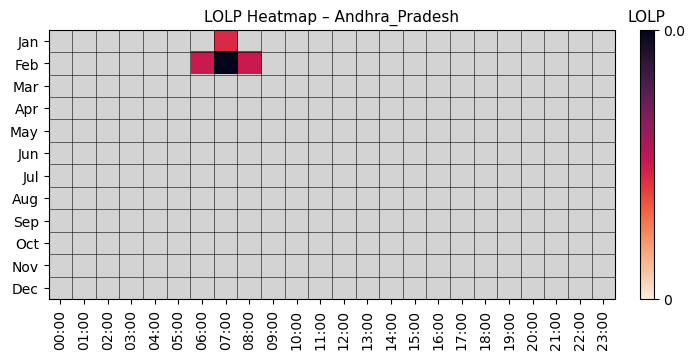

Plotting Arunachal_Pradesh...


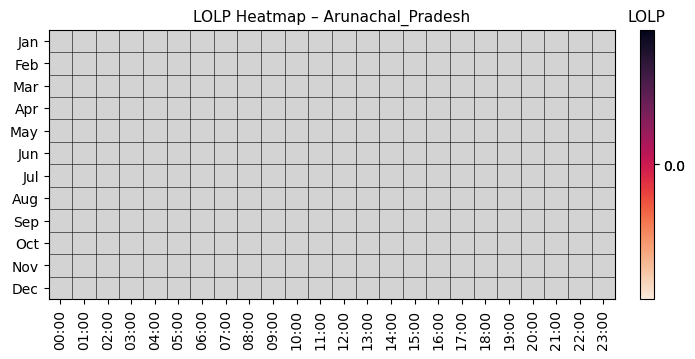

Plotting Assam...


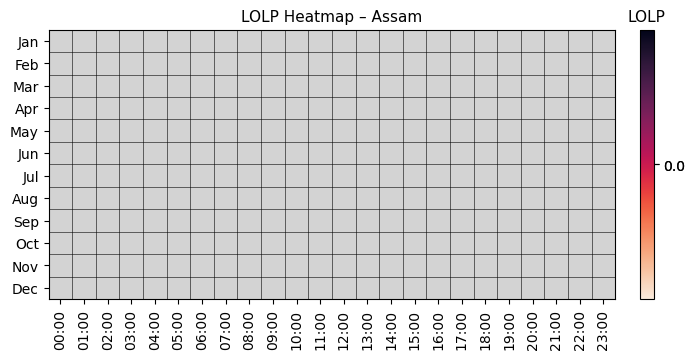

Plotting Bihar...


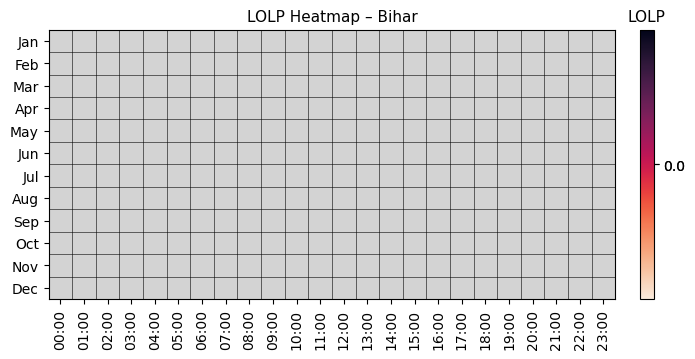

Plotting Chandigarh...


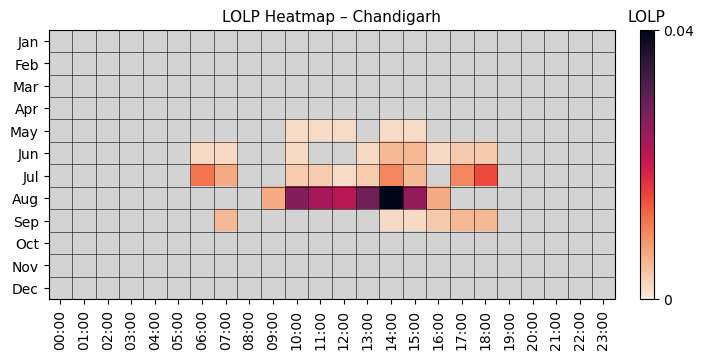

Plotting Chhattisgarh...


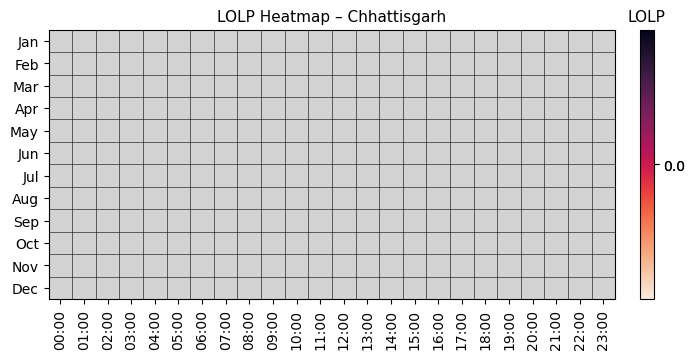

Plotting Dadra_Nagar_Haveli...


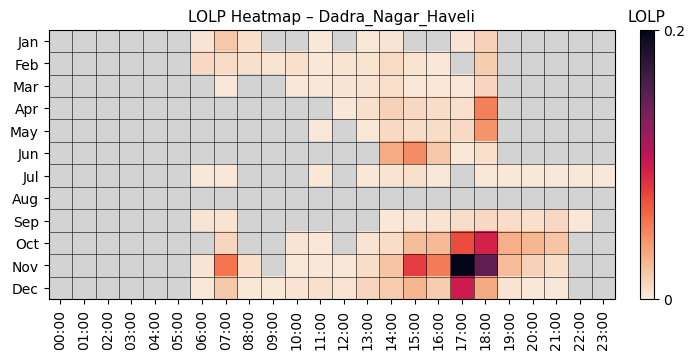

Plotting Daman_Diu...


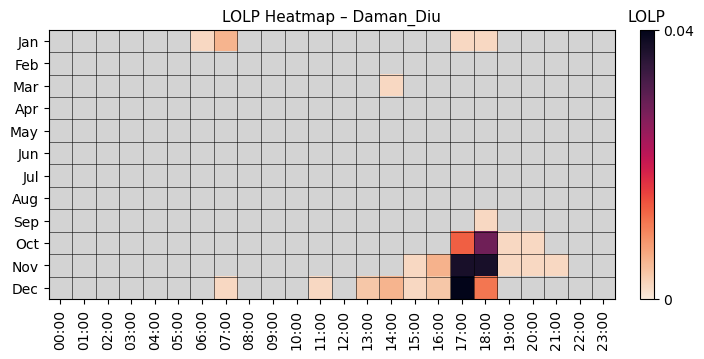

Plotting Delhi...


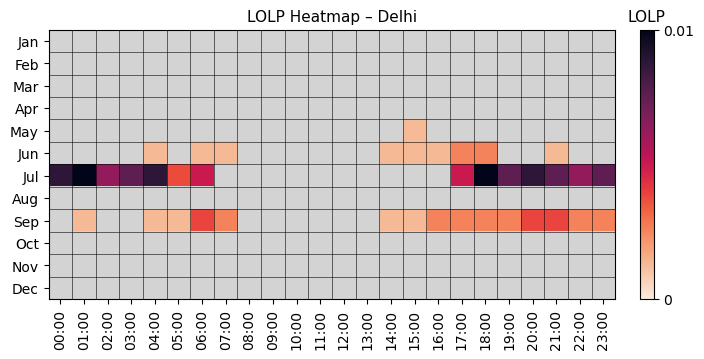

Plotting Goa...


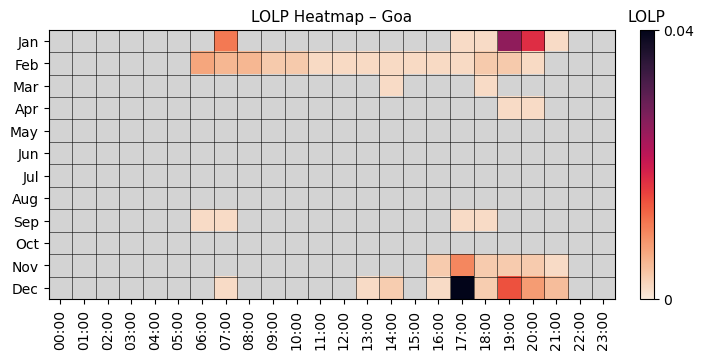

Plotting Gujarat...


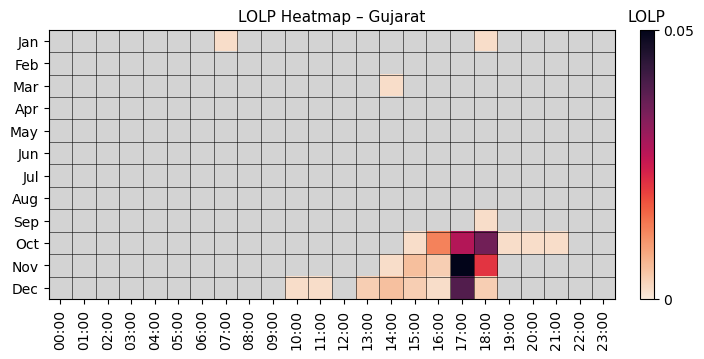

Plotting Haryana...


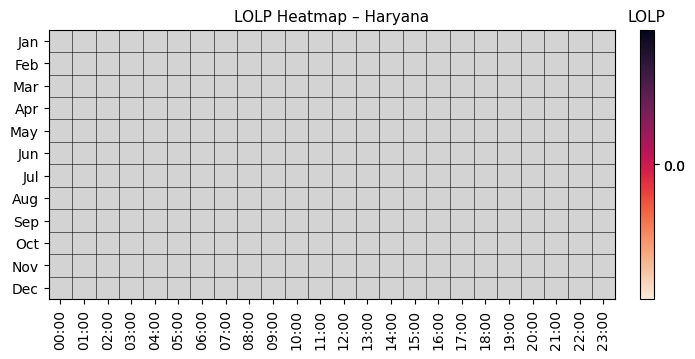

Plotting Himachal_Pradesh...


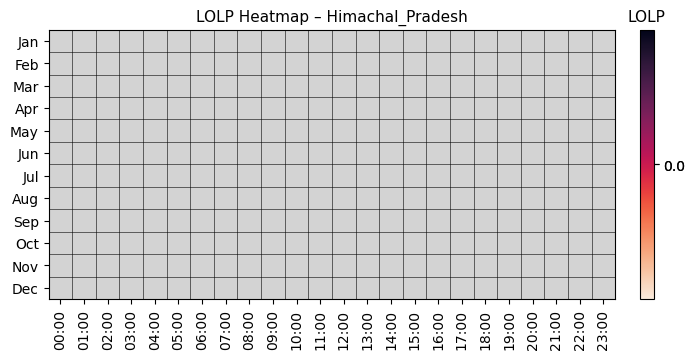

Plotting Jammu_Kashmir...


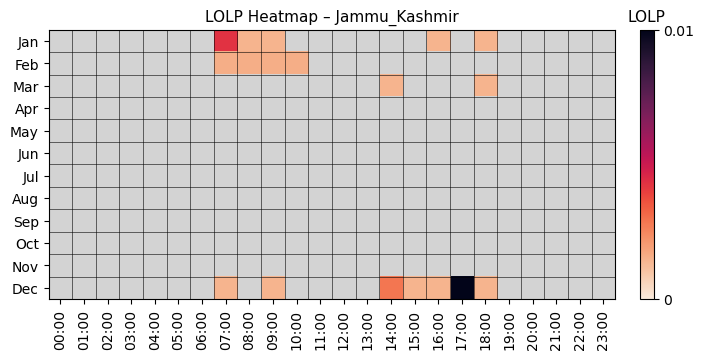

Plotting Jharkhand...


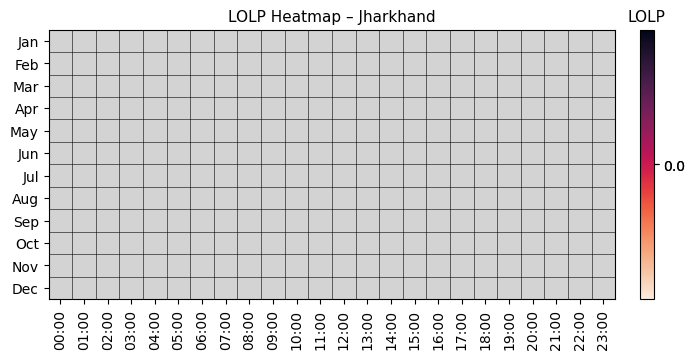

Plotting Karnataka...


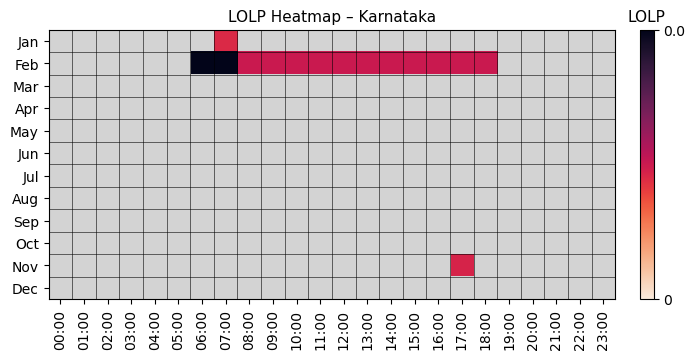

Plotting Kerala...


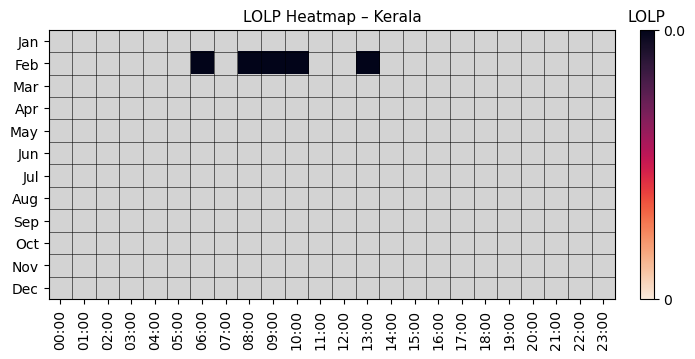

Plotting Madhya_Pradesh...


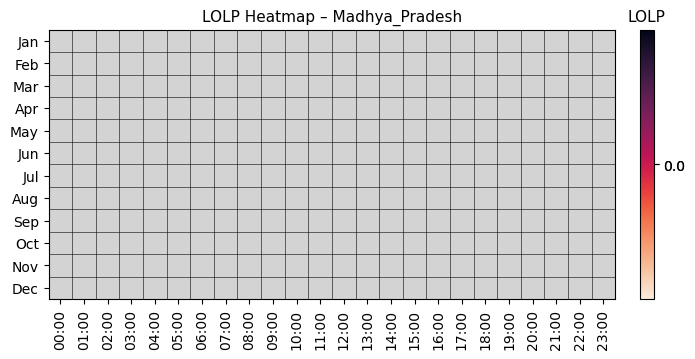

Plotting Maharashtra...


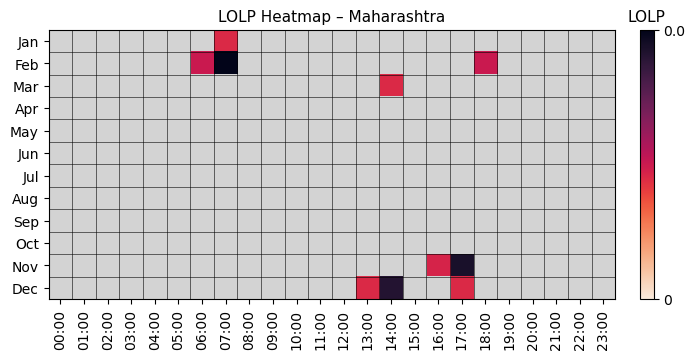

Plotting Manipur...


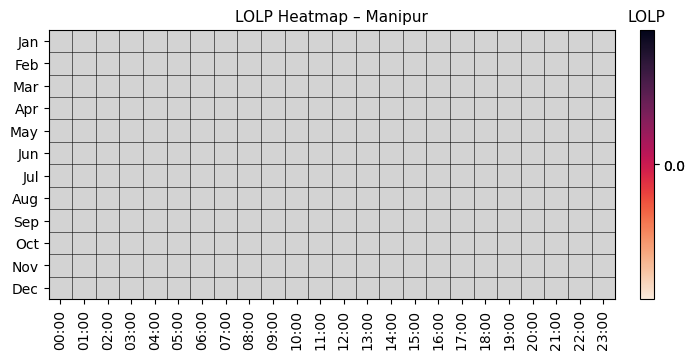

Plotting Meghalaya...


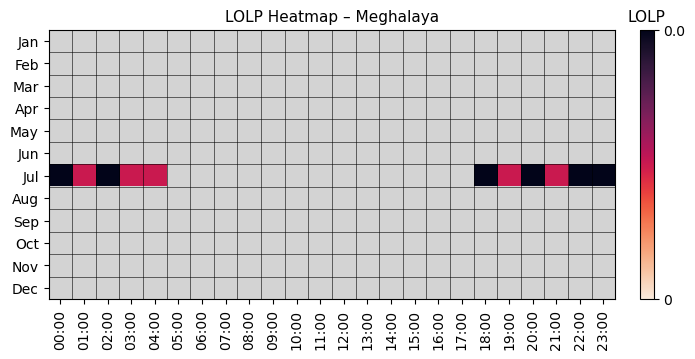

Plotting Mizoram...


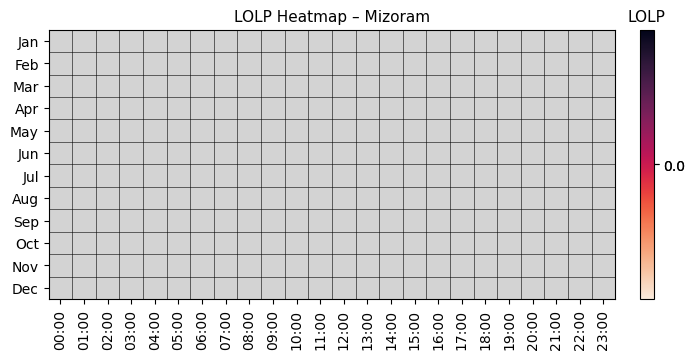

Plotting Nagaland...


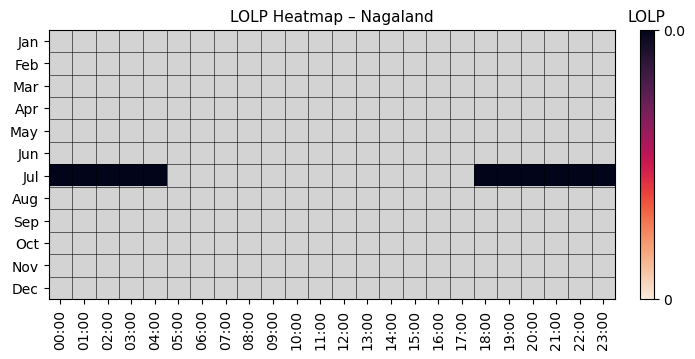

Plotting Odisha...


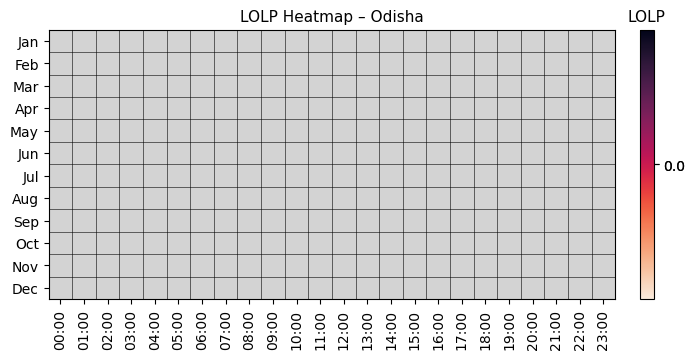

Plotting Puducherry...


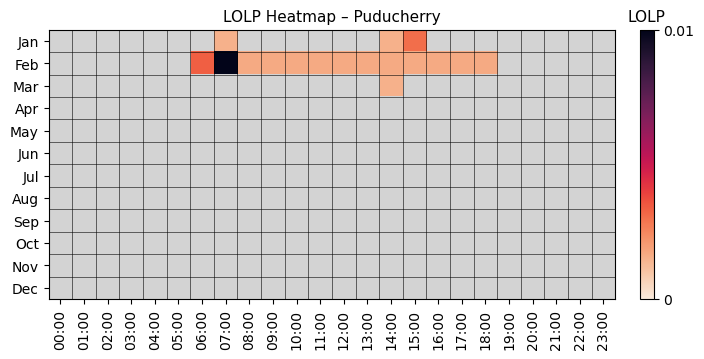

Plotting Punjab...


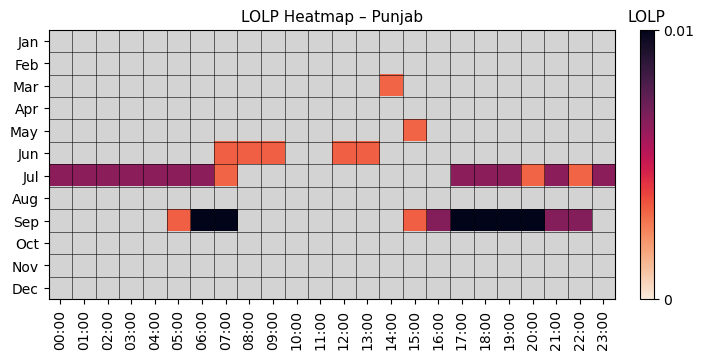

Plotting Rajasthan...


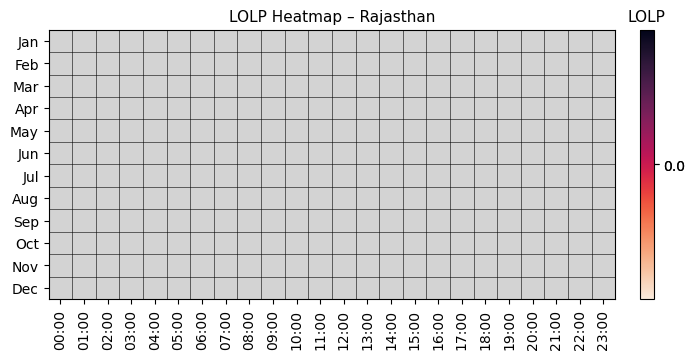

Plotting Sikkim...


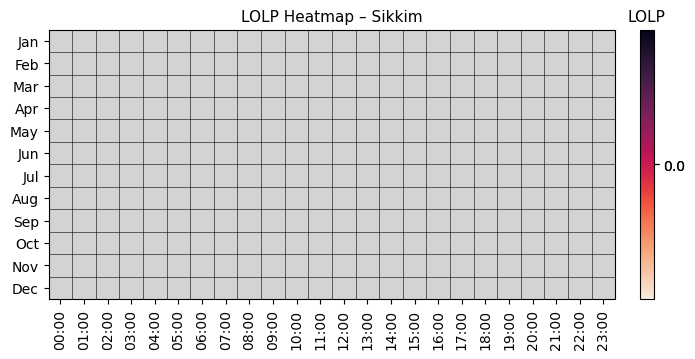

Plotting Tamil_Nadu...


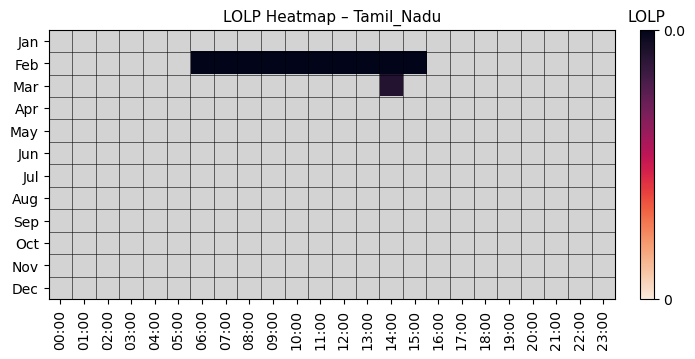

Plotting Telangana...


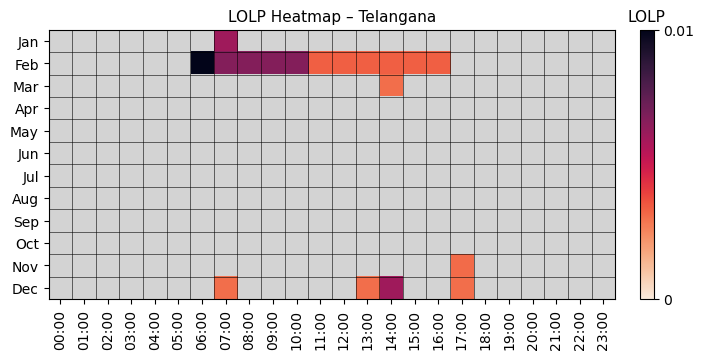

Plotting Tripura...


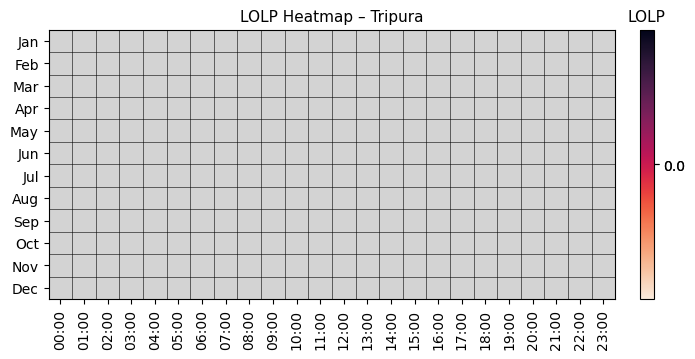

Plotting Uttar_Pradesh...


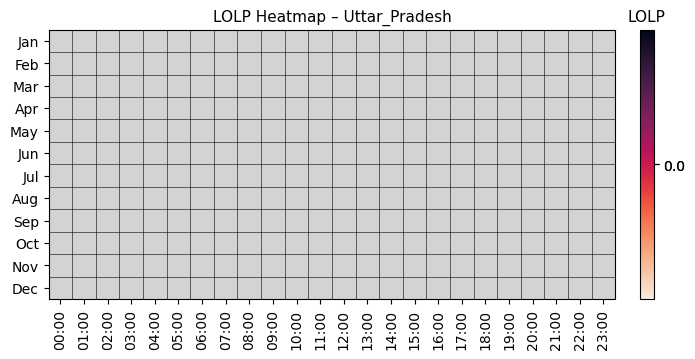

Plotting Uttarakhand...


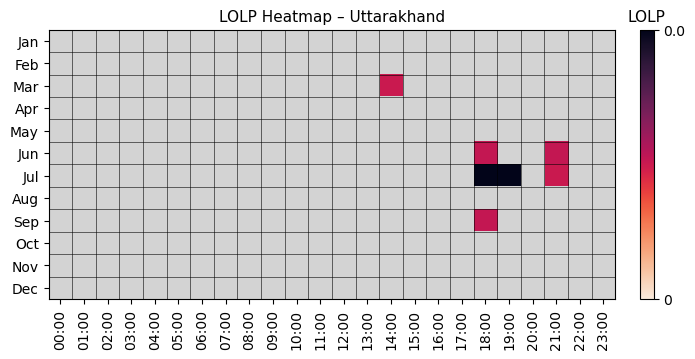

Plotting West_Bengal...


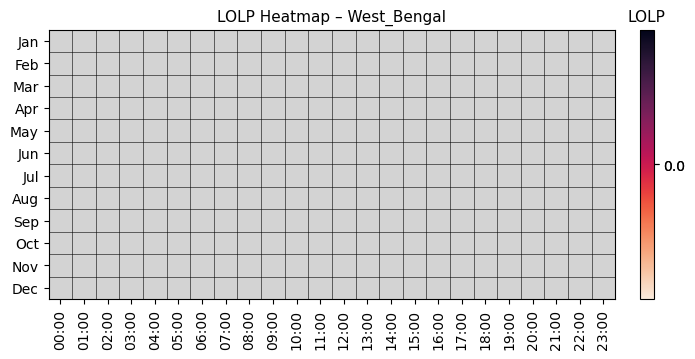

In [ ]:
for z, zone in enumerate(zones):

    LOLP_plot = LOLP_[z, :, :][order_to_calendar, :].astype(float)
    LOLP_plot_masked = LOLP_plot.copy()
    LOLP_plot_masked[LOLP_plot_masked == 0.0] = np.nan

    # --- More compact: shorter vertically, wider horizontally ---
    fig, ax = plt.subplots(figsize=(8, 3.5))  # wider & shorter
    ax.set_facecolor("lightgrey")

    # --- Heatmap ---
    im = ax.imshow(
        LOLP_plot_masked,
        cmap=_cmap,
        vmin=0.0,
        aspect="auto"
    )

    # --- Ticks ---
    ax.set_xticks(np.arange(24), labels=hour_labels, rotation=90)
    ax.set_yticks(np.arange(12), labels=month_labels)

    # --- Gridlines ---
    ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
    ax.grid(which="minor", color="k", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # --- Colorbar ---
    data_max = float(np.nanmax(LOLP_plot)) if np.isfinite(np.nanmax(LOLP_plot)) else 1.0
    sm = cm.ScalarMappable(norm=plt.Normalize(vmin=0.0, vmax=data_max), cmap=_cmap)

    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_ticks([0.0, data_max])
    cbar.set_ticklabels(["0", f"{np.round(data_max, 2)}"])
    cbar.ax.set_title("LOLP", rotation=0, size=11)

    ax.set_title(f"LOLP Heatmap – {zone}", fontsize=11)

    plt.show()
    plt.close()


# LOLP heatmaps by regions

In [16]:
region_info={'Andhra_Pradesh ':	'Southern',
'Arunachal_Pradesh ':	'North-Eastern',
'Assam ':	'North-Eastern',
'Bihar ':	'Eastern',
'Chandigarh ':	'Northern',
'Chhattisgarh ':	'Central',
'Dadra_Nagar_Haveli ':	'Western',
'Daman_Diu ':	'Western',
'Delhi ':	'Northern',
'Goa ':	'Western',
'Gujarat ':	'Western',
'Haryana ':	'Northern',
'Himachal_Pradesh ':	'Northern',
'Jammu_Kashmir ':	'Northern',
'Jharkhand ':	'Eastern',
'Karnataka ':	'Southern',
'Kerala ':	'Southern',
'Madhya_Pradesh ':	'Central',
'Maharashtra ':	'Western',
'Manipur ':	'North-Eastern',
'Meghalaya ':	'North-Eastern',
'Mizoram ':	'North-Eastern',
'Nagaland ':	'North-Eastern',
'Odisha ':	'Eastern',
'Puducherry ':	'Southern',
'Punjab ':	'Northern',
'Rajasthan ':	'Northern',
'Sikkim ':	'North-Eastern',
'Tamil_Nadu ':	'Southern',
'Telangana ':	'Southern',
'Tripura ':	'North-Eastern',
'Uttar_Pradesh ':	'Central',
'Uttarakhand ':	'Central',
'West_Bengal ':	'Eastern'}

Regions: ['Central', 'Eastern', 'North-Eastern', 'Northern', 'Southern', 'Western']
LOLP_region shape: (6, 12, 24)
Plotting region: Central


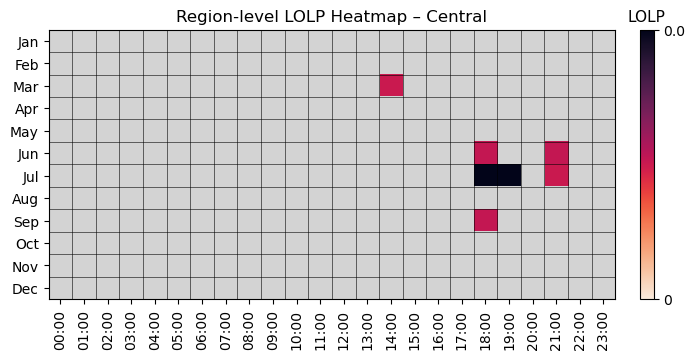

Plotting region: Eastern


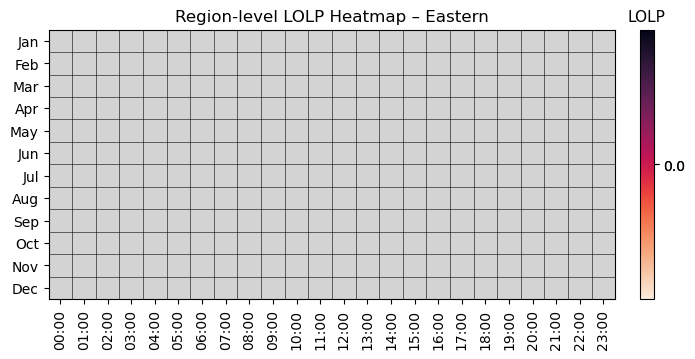

Plotting region: North-Eastern


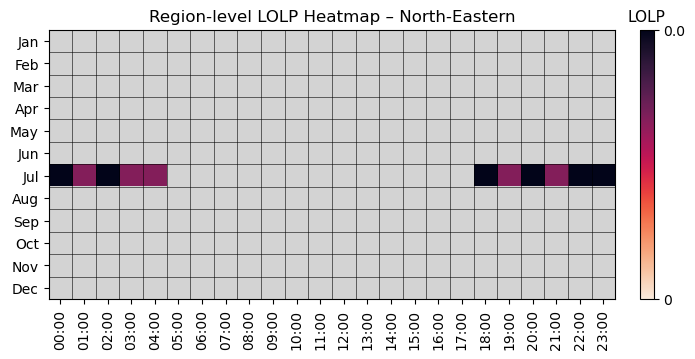

Plotting region: Northern


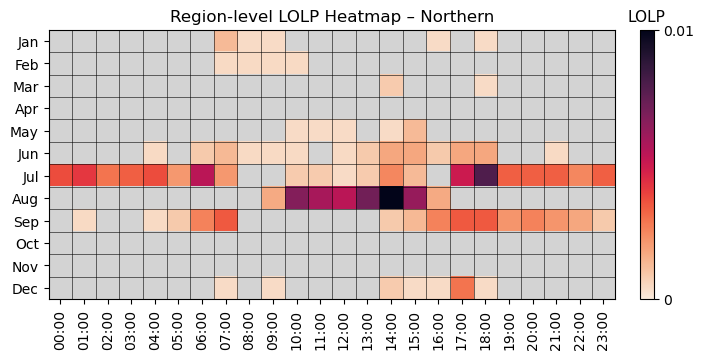

Plotting region: Southern


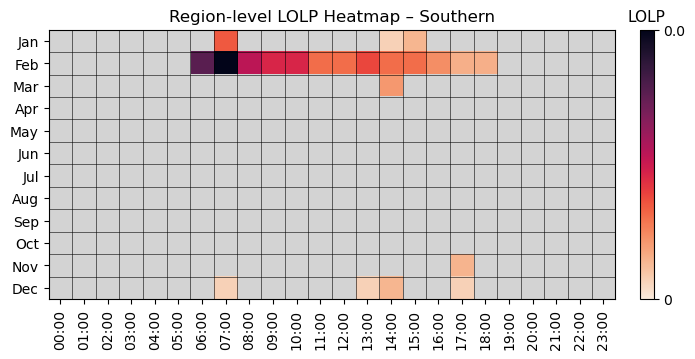

Plotting region: Western


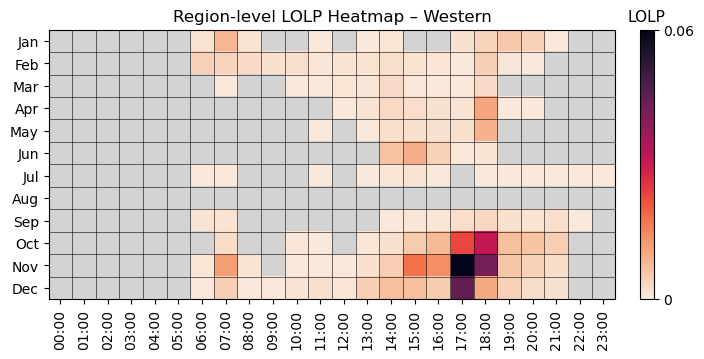

In [ ]:
# Clean zone names (remove trailing spaces from original zones)
zones_clean = [z.strip() for z in zones]
region_info_clean = {k.strip(): v for k, v in region_info.items()}

# Map each zone → region
zone_to_region = {zone: region_info_clean.get(zone, "Unknown") for zone in zones_clean}

# -----------------------------
# Aggregate LOLP by region
# -----------------------------
regions = sorted(set(zone_to_region.values()))
num_regions = len(regions)

LOLP_region = np.zeros((num_regions, 12, 24))

for r, region in enumerate(regions):
    region_indices = [i for i, z in enumerate(zones_clean) if zone_to_region[z] == region]
    if not region_indices:
        continue
    LOLP_region[r, :, :] = np.mean(LOLP_[region_indices, :, :], axis=0)

print("Regions:", regions)
print("LOLP_region shape:", LOLP_region.shape)  # (num_regions, 12, 24)

# -----------------------------
# Plotting region-level heatmaps
# -----------------------------
order_to_calendar = [9, 10, 11, 0, 1, 2, 3, 4, 5, 6, 7, 8]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
hour_labels  = [f'{h:02d}:00' for h in np.arange(24, dtype=int)]

# Colormap
_cmap = sns.color_palette("rocket_r", as_cmap=True)
_cmap.set_bad(color="lightgrey")

for r, region in enumerate(regions):
    print(f"Plotting region: {region}")

    LOLP_plot = LOLP_region[r, :, :][order_to_calendar, :].astype(float)

    # Mask zeros
    LOLP_plot_masked = LOLP_plot.copy()
    LOLP_plot_masked[LOLP_plot_masked == 0.0] = np.nan

    # --- Compact figure: shorter height, wider width ---
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.set_facecolor("lightgrey")

    im = ax.imshow(
        LOLP_plot_masked,
        cmap=_cmap,
        vmin=0.0,
        aspect="auto"
    )

    # --- Ticks and labels ---
    ax.set_xticks(np.arange(24), labels=hour_labels, rotation=90)
    ax.set_yticks(np.arange(12), labels=month_labels)

    # Gridlines for each cell
    ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
    ax.grid(which="minor", color="k", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # --- Colorbar ---
    data_max = float(np.nanmax(LOLP_plot)) if np.isfinite(np.nanmax(LOLP_plot)) else 1.0
    sm = cm.ScalarMappable(norm=plt.Normalize(vmin=0.0, vmax=data_max), cmap=_cmap)

    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_ticks([0.0, data_max])
    cbar.set_ticklabels(["0", f"{np.round(data_max, 2)}"])
    cbar.ax.set_title("LOLP", rotation=0, size=11)

    ax.set_title(f"Region-level LOLP Heatmap – {region}", fontsize=12)

    plt.show()
    plt.close()
